In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [3]:
### initializing variables ###

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
### working with dataset ###

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "training/PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE),
    batch_size = BATCH_SIZE
)
print(dataset)

Found 2152 files belonging to 3 classes.


ValueError: 'size' must be a 1-D Tensor of 2 elements: new_height, new_width

In [ ]:
### class names ###

class_name = dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
len(dataset)

68

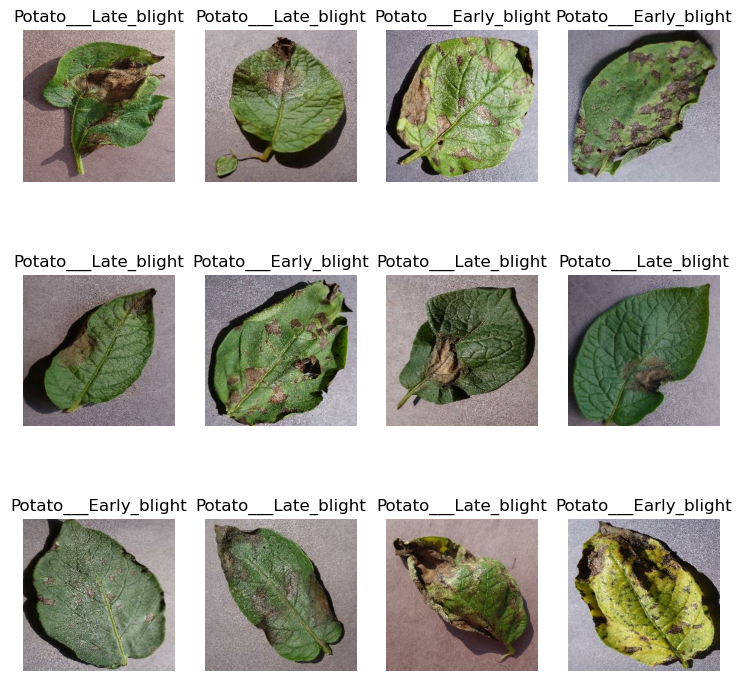

In [ ]:
### visualizing dataset ###

plt.figure(figsize=(9,9))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
     ax = plt.subplot(3,4, i+1)
     plt.imshow(image_batch[i].numpy().astype("uint8"))
     plt.title(class_name[label_batch[i]])
     plt.axis("off")
    
   

In [ ]:
### spliting data ###

training_size = 0.8
len(dataset) * training_size


54.400000000000006

In [ ]:
train_ds = dataset.take(54)
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [ ]:
val_size = 0.1
len(dataset) * val_size

6.800000000000001

In [ ]:
val_ds = dataset.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [ ]:
### function to split train,validation,test ###

def get_dataset_partition_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 1000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds

In [ ]:
### calling the function ###

train_ds,val_ds,test_ds = get_dataset_partition_tf(dataset)

In [ ]:
len(train_ds)
len(val_ds)
len(test_ds)

8

In [ ]:
### caching and pre-fetching data ###

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [ ]:
### layer of image pre-processing pipeline ###

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [ ]:
### image augmentation ###

image_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [ ]:
# cnn model building #

input_shape = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    image_augmentation,
    layers.Conv2D(32, (3,3), activation="relu", input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")

])
model.build(input_shape=input_shape)

C:\Users\Student\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [ ]:
### training the model ###

history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 995ms/step - accuracy: 0.5307 - loss: 0.8774 - val_accuracy: 0.7066 - val_loss: 0.6944
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 877ms/step - accuracy: 0.7847 - loss: 0.5277 - val_accuracy: 0.7870 - val_loss: 0.4494
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 940ms/step - accuracy: 0.8704 - loss: 0.3206 - val_accuracy: 0.8038 - val_loss: 0.4881
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 903ms/step - accuracy: 0.8571 - loss: 0.3548 - val_accuracy: 0.8767 - val_loss: 0.2994
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 912ms/step - accuracy: 0.9167 - loss: 0.2412 - val_accuracy: 0.7656 - val_loss: 0.4881
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 880ms/step - accuracy: 0.9265 - loss: 0.1823 - val_accuracy: 0.7477 - val_loss: 0.7030
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 843ms/step - accuracy: 0.9358 - loss: 0.1699 - val_accuracy: 0.6562 - val_loss: 1.3643
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 955ms/step - accuracy: 0.9508 - loss: 0.1447 - val_accu

In [ ]:
model.evaluate(test_ds)

54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9873 - loss: 0.0409


[0.040909215807914734, 0.9872685074806213]

In [ ]:
history

In [ ]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

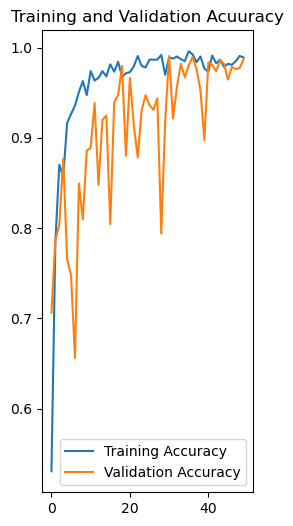

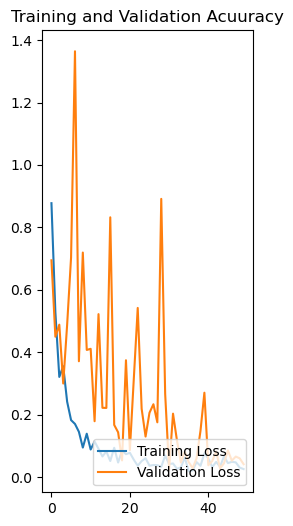

In [ ]:
### ploting graph for accuracy and loss ###

plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Acuuracy")
plt.show()

plt.figure(figsize=(6,6))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc="lower right")
plt.title("Training and Validation Acuuracy")
plt.show()

First image to predict
Actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
Predicted label:  Potato___Early_blight


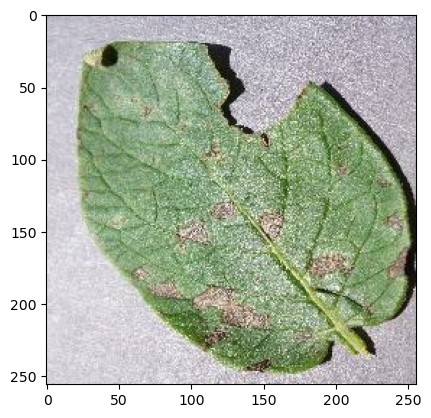

In [ ]:
### prediction loop ###

for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()

    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label: ", class_name[first_label])

    batch_prediction = model.predict(image_batch)
    print("Predicted label: ", class_name[np.argmax(batch_prediction[0])])

In [ ]:
### prediction function with confidence calculation ###

def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img.numpy())
    img_array = tf.expand_dims(img_array, 0) # create a batch

    prediction = model.predict(img_array)

    predicted_class = class_name[np.argmax(prediction[0])]
    confidence = round(100 * (np.max(prediction[0])), 2)

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


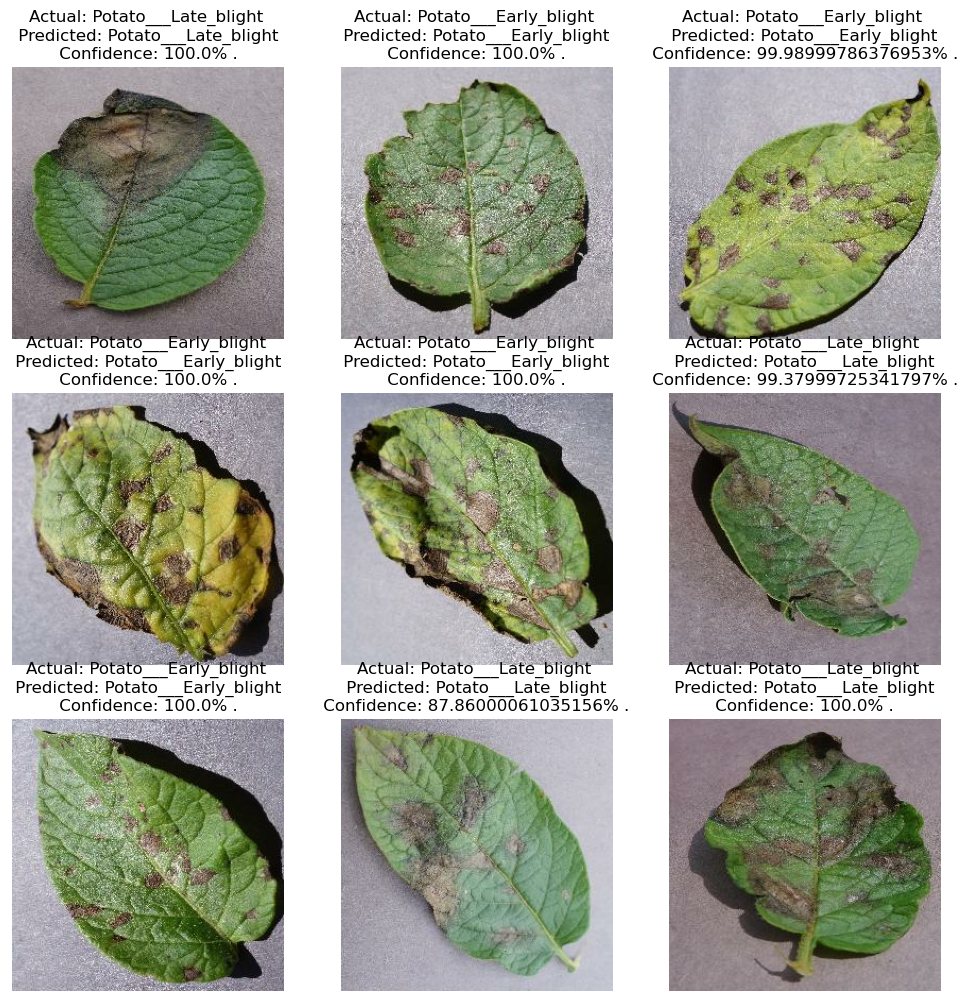

In [ ]:
plt.figure(figsize=(12,12))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i])
        actual_class = class_name[labels[i].numpy()]
        plt.title(f"Actual: {actual_class} \n Predicted: {predicted_class} \n Confidence: {confidence}% . ")
        plt.axis("off")

In [ ]:
import os

model_dir = "./models"
os.makedirs(model_dir, exist_ok=True)

# Determine next version
model_versions = [int(f) for f in os.listdir(model_dir) if f.isdigit()]
next_version = max(model_versions + [0]) + 1

# Save as TensorFlow SavedModel (for TF Serving / TFLite)
save_path = os.path.join(model_dir, str(next_version))
model.export(save_path)

print(f"Model exported at: {save_path}")

INFO:tensorflow:Assets written to: ./models\1\assets


INFO:tensorflow:Assets written to: ./models\1\assets


Saved artifact at './models\1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2083789161872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083787484112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083787484304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789718736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789723536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789723152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789724112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789721040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789724304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789723920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2083789725264: TensorSpec(shape=(), dtyp